# Pricing American Options - Erdös Institute Quantative Finance Project
### **Nathan Burns**
*The use of AI in the project is entirely restricted to in-line suggestions provided by copilot set to 'low' eagerness (this is a feature of VS studio). Any code that taken from another source is referenced.*

In this project, we will investigate the various procedures on the pricing of American-style options.
American-style options differ from European-style options in that they can be exercised at any time prior to the expiration date, in this notebook we will investigate various different methods of pricing these kinds of options. Of course the main difficulty in doing so is taking the benefit of early exercise into account. The methods we shall look at are the 
1. The Binomial Tree Model
2. The Longstaff-Schwartz Monte-Carlo Method.
3. The Bjerksund and Stensland Approximation.

We will finally look at the so-called *perpetual put option*, which behaves somewhat more nicely than its finite time counter-part.

In [1]:
#Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import poisson
import time
import yfinance as yf

#This line is reckless and should be turned off at all times, but I am using it here to suppress warnings from the regression step in the Longstaff and Schwartz method.
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Define functions for Black-Scholes pricing of European options. 
#This code was provided by the instructor and is not my original work. These functions will be used later to comparte the prices of American options to their European counterparts.
def bs_put(S,K,sigma,t,r):
    '''

    Inputs:
    S(float): spot price
    K(float): strike price
    sigma(float): volatility
    t(float): time to expiration
    r(float): risk-free interest rate

    Output:
    Black-Scholes Price of Put Option
    
    '''

    d1 = (np.log(S/K) + (r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    put_price = -S*norm.cdf(-d1) + np.exp(-r*t)*K*norm.cdf(-d2)

    return put_price

def bs_call(S,K,sigma,t,r):
    '''

    Inputs:
    S(float): spot price
    K(float): strike price
    sigma(float): volatility
    t(float): time to expiration
    r(float): risk-free interest rate

    Output:
    Black-Scholes Price of Call Option
    
    '''

    d1 = (np.log(S/K) + (r+(0.5)*sigma**2)*t)/(sigma*np.sqrt(t))
    d2 = d1 - sigma*np.sqrt(t)

    call_price = S*norm.cdf(d1) - np.exp(-r*t)*K*norm.cdf(d2)

    return call_price


## Part 1: The Binomial Tree Model

The Binomial model assumes that a stock price follows a discrete time process. Assuming that time starts at $0$ and has an expiration date of $T$, we decompose the interval $[0,T]$ into $n$ equal time steps of length $\Delta t = \frac{T}{n}$. At each time interval, the stock price will either move up or down a specific factor, which we will denote by $u$ and $d$ respectively ($u \geq 1, 0 < d \leq 1$), with probability $p$ and $1-p$ respectively. 

For example, if $S$ is the current price of underlying stock, then at the next discrrete time step, the price will either be $S_{up} = u \cdot S$ or $S_{down} = d \cdot S$. 

<div align="center">
<pre>
    S0
    /    \
      uS0    dS0
     /   \   /   \
   u²S0  udS0  d²S0
    / \   / \   / \
 u³S0 u²dS0 ud²S0 d³S0
</pre>
</div>

For our investigation, we will impliment the Cox, Ross and Rubinstein (CRR) method of generating the full binomial tree. This method chooses $u$, $d$ and $p$ so that the binomial distribution simulates the geometric brownian motion. In particular, we choose $u = e^{\sigma \sqrt{\Delta t}}$ and $d = \frac{1}{u}$, where $\sigma$ is the stocks underlying (fixed) volatility, and 

$$
p = \frac{e^{r\Delta t} - d}{u-d},
$$
where $r$ is the assumed risk-free interest rate.

### Using the Binomial Tree to Price American Options.

The difficulty in pricing an American-style option comes from the ability to exercise prematurely, allowing for an infinite number of exercise polocies. Indeed, even when given a known stock path and option data, it can be very difficult (sometimes impossible) to find a closed form value of the option at any given time. The price of the option at a given time depends on the ability to exercise immediately, weighed against the option of continuing to wait. In the following, we assume $K$ is the strike price of the option.

Given the binomial tree of stock values, we may compute the value of option at all nodes at the final time; since waiting is no longer a possibility, we know that if the price is $S_{n}$, the option value is 

$$
\begin{cases}
\max\{(S_{n} - k), 0\} & \text{call option}, \\
\max\{(K - S_{n}), 0\} & \text{put option.}
\end{cases}
$$

Once we know the value at each of the final nodes, we can begin to step back through the tree, as we are readily able to compare the value of exercising now against waiting a discrete time step. Depending on the style of option, this step may change. For an America-style option, the technique is to compare the so-called *binomial value* (the fair price of the derivative in that point in time given the evolution of the stock price), against the exercise price. The binomial value $C_{t,i}$ at time step $t$ at node $i$ is given by

$$
C_{t - \Delta t,i} = e^{-r\Delta t}\left(pC_{t,i} + (1 - p)C_{t,i+1}\right).
$$

Therefore, at each step, the value of the option at the initial time is given by 

$$
    \text{Value} = \begin{cases}
        \max\{C_{t,i}, S_{i} - K\} & \text{call option}, \\
        \max\{C_{t,i}, K - S_{i}\} & \text{put option}.
        \end{cases}
$$

Iterating this procedure until we are back at the initial node will provide the value of the derivative at purchase. We impliment this procedure in the two following blocks of code.


In [3]:
#Creates a binomial tree to price an American call option. 
#This code was written by me with AI assistance restricted to in-line suggestions, as per the preamble. All comments are original and written by me.

def american_call(S,K,sigma,T,r,N):
    """
    Computes the price of an American call option using a binomial tree.

    Parameters:
    S (float): Current stock price
    K (float): Strike price
    sigma (float): Volatility of the underlying stock
    T (float): Time to maturity in years
    r (float): Risk-free interest rate
    N (int): Number of steps in the binomial tree

    Returns:
    float: Price of the American call option
    """

    #Calculate the time step and the up and down factors.
    delta_t = T/N 
    up = np.exp(sigma*np.sqrt(delta_t))
    down = 1/up

    #Create the stock price tree.
    stk = np.zeros((N+1,N+1))
    for i in range(N+1):
        for j in range(i+1):
            stk[i,j] = S*(up**(i-j))*(down**(j))
    
    #Calculate the risk-neutral probability. 
    p = (np.exp(r * delta_t) - down)/(up - down)

    #We compute the value of exercising the option at each node and store this in a matrix. 
    exercise_prices = np.zeros((N+1,N+1))
    for i in range(N+1):
        for j in range(i+1):
            exercise_prices[i,j] = max(stk[i,j] - K, 0)
    
    #Initialize an array to store the option price at each node. We will compare the biomial price to the exercise price.
    binomial = np.zeros((N+1,N+1))
    binomial[N,:] = exercise_prices[N,:]

    #Step backwards through the tree to calculate the option price at each node.
    for i in range(N-1,-1,-1):
        for j in range(i+1):
            binomial[i,j] = max(np.exp(-r*delta_t)*((p) *binomial[i+1,j]+(1-p)*binomial[i+1,j+1]), exercise_prices[i,j])
    
    #Return the price of the option at time 0, which is the value at the root of the tree.
    return binomial[0,0]

In [4]:
#Creates a binomial tree to price an American put option. Code copied and modified from the American call option function.
#This code was written by me with AI assistance restricted to in-line suggestions, as per the preamble. All comments are original and written by me.

def american_put(S,K,sigma,T,r,N):
    """
    Computes the price of an American put option using a binomial tree.

    Parameters:
    S (float): Current stock price
    K (float): Strike price
    sigma (float): Volatility of the underlying stock
    T (float): Time to maturity in years
    r (float): Risk-free interest rate
    N (int): Number of steps in the binomial tree

    Returns:
    float: Price of the American put option
    """

    #Calculate the time step and the up and down factors.
    delta_t = T/N 
    up = np.exp(sigma*np.sqrt(delta_t))
    down = 1/up

    #Create the stock price tree.
    stk = np.zeros((N+1,N+1))
    for i in range(N+1):
        for j in range(i+1):
            stk[i,j] = S*(up**(i-j))*(down**(j))
    
    #Calculate the risk-neutral probability.
    p = (np.exp(r * delta_t) - down)/(up - down)

    #We compute the value of exercising the option at each node and store this in a matrix. 
    exercise_prices = np.zeros((N+1,N+1))
    for i in range(N+1):
        for j in range(i+1):
            exercise_prices[i,j] = max(K - stk[i,j], 0)
    
    #Initialize an array to store the option price at each node. We will compare the biomial price to the exercise price.
    binomial = np.zeros((N+1,N+1))
    binomial[N,:] = exercise_prices[N,:]

    #Step backwards through the tree to calculate the option price at each node.
    for i in range(N-1,-1,-1):
        for j in range(i+1):
            binomial[i,j] = max(np.exp(-r*delta_t)*((p) *binomial[i+1,j]+(1-p)*binomial[i+1,j+1]), exercise_prices[i,j])
    
    #Return the price of the option at time 0, which is the value at the root of the tree.
    return binomial[0,0]

Using our previous implementations, we wish to compare the value of American-style options with their European counterparts. We begin by comparing call options.

In [5]:
#We will generate some random parameter to test our functions against the Black-Scholes prices of European call options.
#Intuitively, we expect the American options to be worth more than their European counterparts,the prices of European options with the same parameters.

#We will always use the same time to maturity and risk-free rate for simplicity. We will vary the spot price, strike price, and volatility.
T = 1
r = 0.038

for i in range(10):
    #Define the parameters using a uniform distribution. 
    #To ensure we don't get bizarre parameter combinations, we will set the strike price to be between 80% and 120% of the spot price.
    S0 = int(np.random.uniform(50,150))
    K = int(np.random.uniform(S0*0.8,S0*1.2))
    sigma = np.random.uniform(0.1,0.5)
    N = 1000

    am_call_price = american_call(S0,K,sigma,T,r,N)
    eu_call_price = bs_call(S0,K,sigma,T,r)

    print(f"Parameters: S0={S0:.2f}, K={K:.2f}, sigma={sigma:.2f}")
    print(f"American Call Price: {am_call_price:.2f}, European Call Price: {eu_call_price:.2f}")
    print("---"*30)

Parameters: S0=73.00, K=64.00, sigma=0.48
American Call Price: 19.31, European Call Price: 19.31
------------------------------------------------------------------------------------------
Parameters: S0=110.00, K=113.00, sigma=0.21
American Call Price: 9.85, European Call Price: 9.85
------------------------------------------------------------------------------------------
Parameters: S0=129.00, K=139.00, sigma=0.31
American Call Price: 13.79, European Call Price: 13.79
------------------------------------------------------------------------------------------
Parameters: S0=100.00, K=95.00, sigma=0.49
American Call Price: 23.18, European Call Price: 23.17
------------------------------------------------------------------------------------------
Parameters: S0=80.00, K=84.00, sigma=0.45
American Call Price: 13.96, European Call Price: 13.96
------------------------------------------------------------------------------------------
Parameters: S0=145.00, K=140.00, sigma=0.28
American Call

We can see that in general, the price of American and European-style *call* options end up being similar in price.

***The following exposition is adapted from Lecture notes (specifically lecture 15) by Professor Steve Lalley at the University of Chicago. These notes are available online at https://www.stat.uchicago.edu/~lalley/Courses/391.***

For an American-style call option, the optimal policy is to hold the option until expiration. To see why, let $\tau < T$ be any stopping time. Exercising the option at time $\tau$ would imply that the discounted value at the initial time to the holder of the option is given by 
$$
E[\max\{(S_{\tau} - K),0\} \cdot e^{-r\tau}] \leq E[\max\{S_{\tau} \cdot e^{-r\tau} - K \cdot e^{-rT}, 0\}].
$$
Some mathematics involving Jensen's inequality can then be used to say that 
$$
E[\max\{S_{\tau} \cdot e^{-r\tau} - K \cdot e^{-rT}, 0\}] \leq E[\max\{S_{T} \cdot e^{-rT} - K \cdot e^{-rT}, 0\}],
$$
and so a policy of exercising at time $\tau < T$ must have a lower value than the correponding European-call option at expiration $T$. Since we expect the value of the American call option to be larger than that of the European call option, we must therefore conclude that they have the same value and the optimal policy is to hold until expiration (this can be made rigorous). 

The same is **not** true for American and European-style *put* options, as we will now demonstrate in the next block of code.

In [6]:
#As before, we will generate some random parameter to test our functions against the Black-Scholes prices of European put options.

#We will always use the same time to maturity and risk-free rate for simplicity. We will vary the spot price, strike price, and volatility.
T = 1
r = 0.038

for i in range(10):
    #Define the parameters using a uniform distribution. 
    #To ensure we don't get bizarre parameter combinations, we will set the strike price to be between 80% and 120% of the spot price.
    S0 = int(np.random.uniform(50,150))
    K = int(np.random.uniform(S0*0.8,S0*1.2))
    sigma = np.random.uniform(0.1,0.5)
    N = 1000

    am_put_price = american_put(S0,K,sigma,T,r,N)
    eu_put_price = bs_put(S0,K,sigma,T,r)

    print(f"Parameters: S0={S0:.2f}, K={K:.2f}, sigma={sigma:.2f}")
    print(f"American Put Price: {am_put_price:.2f}, European Put Price: {eu_put_price:.2f}")
    print("---"*30)

Parameters: S0=74.00, K=80.00, sigma=0.17
American Put Price: 7.48, European Put Price: 6.82
------------------------------------------------------------------------------------------
Parameters: S0=123.00, K=132.00, sigma=0.31
American Put Price: 18.14, European Put Price: 17.42
------------------------------------------------------------------------------------------
Parameters: S0=145.00, K=138.00, sigma=0.30
American Put Price: 11.52, European Put Price: 11.13
------------------------------------------------------------------------------------------
Parameters: S0=119.00, K=127.00, sigma=0.15
American Put Price: 9.93, European Put Price: 8.88
------------------------------------------------------------------------------------------
Parameters: S0=73.00, K=71.00, sigma=0.20
American Put Price: 3.92, European Put Price: 3.71
------------------------------------------------------------------------------------------
Parameters: S0=138.00, K=115.00, sigma=0.32
American Put Price: 6.01, 

Unlike the case for the call options, put options behave differently, with the price of the American-style put options being noticeably larger than their European counterparts. 

***As before, we will borrow exposition from the same lecture notes as above. Specifically around Proposition 2.***

If we denote by $V_{E}(t,S_{t})$. and $V_{A}(t,S_{t})$ to be the values at time $t \leq T$ of the European and American put options on the stock asset, both with the same expiration $T$ and strike price $K$, then one may show that 
$$
V_{E}(t,S_{t}) < V_{A}(t,S_{t}).
$$
We will demonstrate this empirically using the binomial tree implementation.

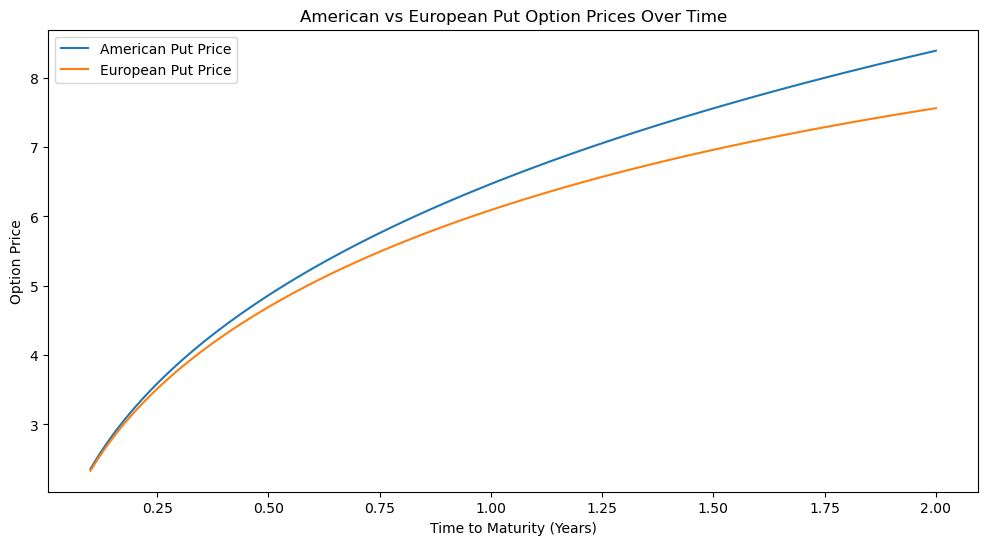

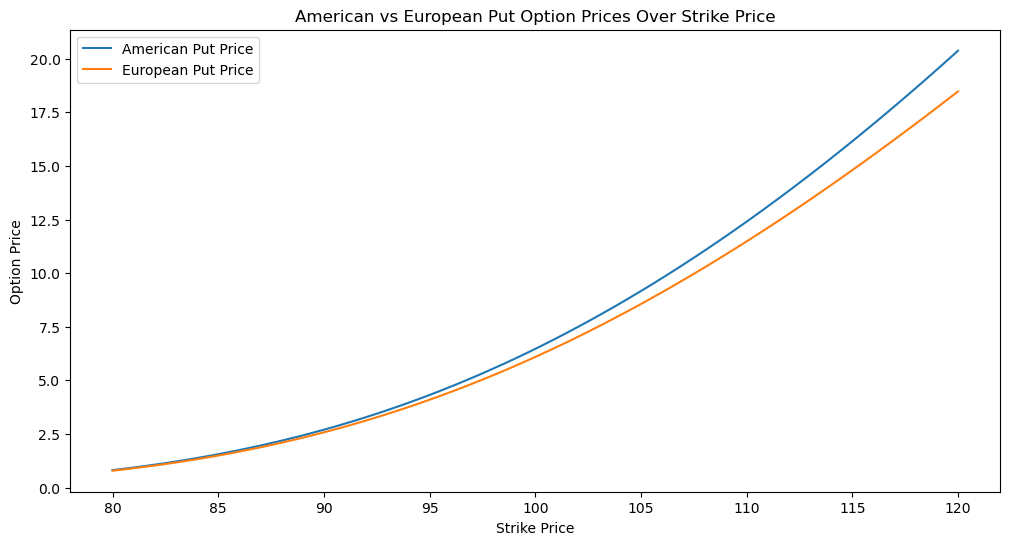

In [7]:
#In this first block, we will increment the time to maturity and compare the prices of American and European put options. We will keep the other parameters constant for simplicity.
S0 = 100
K = 100
sigma = 0.2
r = 0.038
times = np.linspace(0.1,2,100)

am_put_prices = []
eu_put_prices = []
for T in times:
    am_put_prices.append(american_put(S0,K,sigma,T,r,N))
    eu_put_prices.append(bs_put(S0,K,sigma,T,r))

plt.figure(figsize=(12,6))
plt.plot(times, am_put_prices, label='American Put Price')
plt.plot(times, eu_put_prices, label='European Put Price')
plt.title('American vs European Put Option Prices Over Time')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Option Price')
plt.legend()

plt.show()

#In this second block we will increment the strike price from 0.8 to 1.2 times the spot price and compare the prices of American and European put options.
S0 = 100
sigma = 0.2
r = 0.038
T = 1
strike_prices = np.linspace(S0*0.8,S0*1.2,100)

am_put_prices = []
eu_put_prices = []
for K in strike_prices:
    am_put_prices.append(american_put(S0,K,sigma,T,r,N))
    eu_put_prices.append(bs_put(S0,K,sigma,T,r))

plt.figure(figsize=(12,6))
plt.plot(strike_prices, am_put_prices, label='American Put Price')
plt.plot(strike_prices, eu_put_prices, label='European Put Price')
plt.title('American vs European Put Option Prices Over Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.show()

One may prove that for an American put option there exists a function $S_{*}(t)$ for which characterises the optimal time to exercise the option; one should exercise the put at the first time $\tau \leq T$ such that 

$$S_{\tau} \leq s_{*}(\tau).$$

Unfortunately, their is no closed form expression for this function $S_{*}(t)$.

# Part 2: The Longstaff and Schwartz Model - A Monte-Carlo Approach

***The following method and much of the following exposition comes from the original paper by Longstaff and Schwartz:***

*Francis A. Longstaff, Eduardo S. Schwartz, Valuing American Options by Simulation: A Simple Least-Squares Approach, The Review of Financial Studies, Volume 14, Issue 1, January 2001, Pages 113–147, https://doi.org/10.1093/rfs/14.1.113*

The next method we shall investigate to price American-style options is via Monte-Carlo. Given that analytically American and European-style call options have the same value, we hone in specifically on put options.

The general idea remains mostly the same; at the expiration date, the optimal exercise strategy for an American option is to exercise if it is in the money. Prior to the final date, the optimal strategy is to compare the immediate exercise value with the expected cash flows from continuing. Therefore, the key to optimally exercising an American option is identifying the conditional expected value of continuation. 

With the Longstaff and Schwartz Model, this is done by regressing the simulated cash flows from continuation. The following example is ripped directly from the aforementioned paper; consider an American put option on a share of stock. We may compute the value of exercising the option at the time of expiration easily. Then going back a single discrete time step, we may compute the discounted value of holding the option for each stock path. Let $\Delta t$ denote the size of increment between each time step. Let $X$ be the value of the stock at time $T - \Delta t$, and let $Y$ be the discounted value of holding the stock at time $T - \Delta t$. Then using least-squares regression on our stock paths, we may find an expression relating $Y$ to $X$, and use this to compare holding the option at time $T - \Delta t$ versus exercising the option at time $T - \Delta t$.

We will impliment this approach in the following code blocks, first we define a function while simulated stock paths.

In [8]:
#This code was provided by the instructor and is not my original work. It simulates stock price paths using geometric Brownian motion.
def simulate_gbm(S0, sigma, t, n_steps, n_sims):
    dt = t/n_steps
    r = .038
    noise = np.random.normal(size = (n_sims, n_steps))
    log_returns = (r-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*noise
    cum_log_returns = np.cumsum(log_returns, axis = 1)
    cum_log_returns = np.insert(cum_log_returns, 0, 0, axis = 1)
    stock_returns = np.exp(cum_log_returns)
    stock_prices = S0 * stock_returns
    return stock_prices

In [9]:
#Longstaff and Schwartz method for pricing American put options via simulation. 
#This code was written by me with AI assistance restricted to in-line suggestions, as per the preamble. All comments are original and written by me.
n_sims = 10000
n_steps = 100
t = 1

def longstaff_schwartz(S0, K, sigma, t, n_steps, n_sims):
    """
    Runs the Longstaff and Schwartz method to price an American put option.
    Parameters:
    S0 (float): Initial stock price
    K (float): Strike price
    sigma (float): Volatility of the underlying stock
    t (float): Time to maturity in years
    n_steps (int): Number of time steps in the simulation
    n_sims (int): Number of simulated paths

    Returns:
    float: Estimated price of the American put option
    """
    stock_prices = simulate_gbm(S0, sigma, t, n_steps, n_sims)
    dt = t/n_steps
    r = 0.038

    #Calculate the payoff at maturity for a put option.
    payoff = np.maximum(K - stock_prices[:, -1], 0)

    #Calculate the discount factor for one time step.
    discount = np.exp(-r * dt)

    #Step backwards through the time steps to determine the optimal exercise strategy.
    for t in range(n_steps - 1, 0, -1):
        
        S_t = stock_prices[:, t]

        #Find the immediate exercise value at time t.
        exercise = np.maximum((K - S_t), 0)
        
        #We only consider paths where the option is in the money, since we would never exercise an out-of-the-money option.
        itm = exercise > 0
        
        #If there are no in-the-money paths, we can skip the regression and just discount the payoffs.
        if np.sum(itm) == 0:
            payoff *= discount
            continue
        
        #Perform a regression of the discounted payoffs on the stock price to estimate the continuation value.
        X = S_t[itm]
        Y = payoff[itm] * discount
        #We will use a second-degree polynomial for the regression, this of course may be changed. 
        coeffs = np.polyfit(X, Y, 2)
        continuation = np.polyval(coeffs, X)
        
        #We check if exercising the option now is more valuable than continuing to hold the option.
        exercise_now = exercise[itm] > continuation
        
        #Update the payoff for paths where it is optimal to exercise now, and discount the payoff for paths where it is optimal to continue.
        payoff[itm] = np.where(exercise_now, exercise[itm], payoff[itm] * discount)
        
        # Discount non-ITM paths
        payoff[~itm] *= discount

    return np.mean(payoff)

#We will generate some random parameters to test our Longstaff and Schwartz method against the Binomial Tree method for pricing American put options.
for i in range(10):
    S0 = np.random.uniform(120,180)
    K = np.random.uniform(S0*0.8,S0*1.2)
    sigma = np.random.uniform(0.1,0.5)

    print(f"Parameters: S0={S0:.2f}, K={K:.2f}, sigma={sigma:.2f}")
    print(f"Longstaff and Schwartz price: {longstaff_schwartz(S0, K, sigma, t, n_steps, n_sims):.2f}")
    print(f"Binomial Tree Price: {american_put(S0, K, sigma, t, r, 100)}")
    print("---"*30)


Parameters: S0=137.62, K=127.10, sigma=0.15
Longstaff and Schwartz price: 2.39
Binomial Tree Price: 2.4504165581536466
------------------------------------------------------------------------------------------
Parameters: S0=169.32, K=165.11, sigma=0.50
Longstaff and Schwartz price: 27.65
Binomial Tree Price: 27.85862579087267
------------------------------------------------------------------------------------------
Parameters: S0=143.65, K=164.12, sigma=0.40
Longstaff and Schwartz price: 32.47
Binomial Tree Price: 32.84261955004489
------------------------------------------------------------------------------------------
Parameters: S0=147.74, K=150.62, sigma=0.41
Longstaff and Schwartz price: 23.39
Binomial Tree Price: 23.139904793421714
------------------------------------------------------------------------------------------
Parameters: S0=175.32, K=141.83, sigma=0.19
Longstaff and Schwartz price: 1.33
Binomial Tree Price: 1.3525658368385165
----------------------------------------

As we can see, the Longstaff and Schwartz price performs close to the binomial tree price. Given that in both cases, stock path is modelled by geometric brownian motion, it makes sense that as long as we are splitting our time interval into sufficiently small intervals, that the binomial tree model will produce a more accurate price. However, this comes at a significant-time cost, as demonstrated by the next block of code. In this case, each stock path is split into 2000 discrete time steps, and the Longstaff and Schwartz method produces 5000 simulations of said stock path.

In [10]:
#Compare the time of computation of the Longstaff and Schwartz method to the binomial tree method for pricing American put options. We will use the same parameters for both methods to ensure a fair comparison.
t = 1
n_steps = 2000
n_sims = 5000
dt = t/n_steps

for i in range(10):
    S0 = np.random.uniform(120,180)
    K = np.random.uniform(S0*0.8,S0*1.2)
    sigma = np.random.uniform(0.1,0.5)
    print(f"Parameters: S0={S0:.2f}, K={K:.2f}, sigma={sigma:.2f}")
    t0 = time.time()
    am_put_price = american_put(S0,K,sigma,t,r,n_steps)
    t1 = time.time()
    print(f"Binomial Tree Price: {am_put_price:.2f}, Time taken: {t1-t0:.2f} seconds")

    t0 = time.time()
    ls_price = longstaff_schwartz(S0, K, sigma, t, n_steps, n_sims)
    t1 = time.time()
    print(f"Longstaff and Schwartz Price: {ls_price:.2f}, Time taken: {t1-t0:.2f} seconds")
    print("---"*30)

Parameters: S0=127.28, K=139.58, sigma=0.41
Binomial Tree Price: 25.65, Time taken: 1.61 seconds
Longstaff and Schwartz Price: 25.60, Time taken: 0.72 seconds
------------------------------------------------------------------------------------------
Parameters: S0=175.09, K=173.01, sigma=0.28
Binomial Tree Price: 15.46, Time taken: 1.59 seconds
Longstaff and Schwartz Price: 15.62, Time taken: 0.56 seconds
------------------------------------------------------------------------------------------
Parameters: S0=174.52, K=204.48, sigma=0.45
Binomial Tree Price: 47.02, Time taken: 1.58 seconds
Longstaff and Schwartz Price: 46.97, Time taken: 0.73 seconds
------------------------------------------------------------------------------------------
Parameters: S0=131.95, K=145.35, sigma=0.38
Binomial Tree Price: 25.76, Time taken: 1.56 seconds
Longstaff and Schwartz Price: 25.49, Time taken: 0.63 seconds
------------------------------------------------------------------------------------------


# Part 3 - The Bjerksund and Stensland (1993) Approximation.

Finally, we investigate the Bjerksund and Stensland 1993 approximation. The exposition for this comes from the book "The Complete Guide to Option Pricing Formulas - Espen Haug" at page 101.

In 1993, authors Bjerksund and Stensland came up with an analytical formula for pricing American-style options (both call and put). We will only present the formulas here and not their derivation. 

Given an initial stock price S, stike K, time to expiration T, risk-free interest r, cost of holding asset b = r - dividend yield, and volatility $\sigma$, the Bjerksund and Stenslend model for evaluating American-style call options is given by 
$$
C(S,K,T,r,b,\sigma) = \alpha S^{\beta} - \alpha\phi(S,T,\beta,I,I) + \phi(S,T,1,I,I) - \phi(S,T,1,K,I) - K\phi(S,T,0,I,I) + K\phi(S,T,0,K,I),
$$
where 
$$\alpha = (I - K)I^{-\beta},$$
$$\beta = \left(\frac{1}{2} - \frac{b}{\sigma^{2}}\right) + \sqrt{\left(\frac{b}{\sigma^{2}} - \frac{1}{2}\right)^{2} + \frac{2r}{\sigma^{2}}}.$$
The function $\phi(S,T,\gamma,H,I)$ is given by
$$\phi(S,T,\gamma,H,I) = e^{\lambda}S^{\gamma}\left[N(d) - \left(\frac{I}{S}\right)^{\kappa} N\left(d - \frac{2\ln(I/S)}{\sigma\sqrt{t}} \right)\right],$$
$$\lambda = \left(-r + \gamma b + \frac{1}{2}\gamma(\gamma-1)\sigma^{2}\right)T,$$
$$d = -\frac{\ln(S/H) + \left(b + (\gamma - \frac{1}{2})\sigma^{2}\right)T}{\sigma\sqrt{T}},$$
$$\kappa = \frac{2b}{\sigma^{2}} + (2\gamma - 1),$$
and finally, $I$ is defined as
$$I = B_{0} + (B_{\infty} - B_{0})(1 - e^{h}),$$
$$h = (-bT + 2\sigma\sqrt{T})\left(\frac{B_{0}}{B_{\infty} - B_{0}}\right),$$
$$B_{\infty} = \frac{\beta}{\beta - 1}K,$$
$$B_{0} = \max\left[K, \frac{r}{r- b}K\right].$$

The value of the American put is then given by $P(S,K,T,r,b,\sigma) = C(K,S,T, r-b, -b,\sigma)$. Below is an implementation of this approximation, with lazily few comments.

In [11]:
#All code here is written by me with AI assistance restricted to in-line suggestions, as per the preamble. All comments are original and written by me.
#Here r is the risk free rate, b is the r - dividend yield. These are assumed given.
def phi(S, T, gamma, H, I, r, b, sigma):
    lambda_ = (-r + gamma*b + 0.5*gamma*(gamma - 1)*sigma**2)*T
    d = -(np.log(S/H) + (b + (gamma - 0.5)*sigma**2)*T)/(sigma*np.sqrt(T))
    k = (2*b/sigma**2) + (2*gamma - 1)

    return np.exp(lambda_) * (S**gamma) * (
        norm.cdf(d) - (I/S)**k * norm.cdf(d - (2*np.log(I/S))/(sigma*np.sqrt(T)))
    )

def bjerksund_stensland_call(S, K, T, r, b, sigma):
    beta = (0.5 - b/sigma**2) + np.sqrt(((b/sigma**2 - 0.5)**2) + (2*r/sigma**2))
    B_inf = beta/(beta-1)*K
    B_zero = max(K, r/(r-b)*K)
    h = -(b*T + 2*sigma*np.sqrt(T))*(B_zero/(B_inf-B_zero))
    I = B_zero + (B_inf - B_zero)*(1-np.exp(h))
    alpha = (I-K)*I**(-beta)

    if S >= I:
        return S-K
    else:
        return alpha*S**beta - alpha*phi(S,T,beta,I,I,r,b,sigma) + phi(S,T,1,I,I,r,b,sigma) - phi(S,T,1,K,I,r,b,sigma) - K*phi(S,T,0,I,I,r,b,sigma) + K*phi(S,T,0,K,I,r,b,sigma)
    
def bjerksund_stensland_put(S, K, T, r, b, sigma):
    return bjerksund_stensland_call(K,S,T,r-b,-b,sigma)

The main benefit this approximation enjoys is its computational efficiency, which we will demonstrate below.

In [12]:
t = 1
n_steps = 2000
n_sims = 10000 #We will use more simulations here to exaggerate the time difference between the Longstaff and Schwartz method and the binomial tree method, since we are comparing it to a closed-form approximation.
dt = t/n_steps

for i in range(10):
    S0 = np.random.uniform(120,180)
    K = np.random.uniform(S0*0.8,S0*1.2)
    sigma = np.random.uniform(0.1,0.5)
    print(f"Parameters: S0={S0:.2f}, K={K:.2f}, sigma={sigma:.2f}")
    t0 = time.time()
    am_put_price = american_put(S0,K,sigma,t,r,n_steps)
    t1 = time.time()
    print(f"Binomial Tree Price: {am_put_price:.2f}, Time taken: {t1-t0:.2f} seconds")

    t0 = time.time()
    ls_price = longstaff_schwartz(S0, K, sigma, t, n_steps, n_sims)
    t1 = time.time()
    print(f"Longstaff and Schwartz Price: {ls_price:.2f}, Time taken: {t1-t0:.2f} seconds")

    t0 = time.time()
    bjerk_stens_price = bjerksund_stensland_put(S0, K, t, r, r, sigma)
    t1 = time.time()
    print(f"Bjerksund-Stensland Price: {bjerk_stens_price:.2f}, Time taken: {t1-t0:.2f} seconds")
    print("---"*30)

Parameters: S0=139.50, K=165.41, sigma=0.35
Binomial Tree Price: 33.30, Time taken: 1.60 seconds
Longstaff and Schwartz Price: 33.13, Time taken: 1.47 seconds
Bjerksund-Stensland Price: 33.12, Time taken: 0.00 seconds
------------------------------------------------------------------------------------------
Parameters: S0=153.95, K=156.31, sigma=0.44
Binomial Tree Price: 25.27, Time taken: 1.57 seconds
Longstaff and Schwartz Price: 25.29, Time taken: 1.37 seconds
Bjerksund-Stensland Price: 25.12, Time taken: 0.00 seconds
------------------------------------------------------------------------------------------
Parameters: S0=149.96, K=166.45, sigma=0.17
Binomial Tree Price: 18.40, Time taken: 1.58 seconds
Longstaff and Schwartz Price: 18.56, Time taken: 1.50 seconds
Bjerksund-Stensland Price: 18.24, Time taken: 0.00 seconds
------------------------------------------------------------------------------------------
Parameters: S0=133.88, K=115.27, sigma=0.39
Binomial Tree Price: 9.65, Ti

We note here that in 2002, Bjerksund and Stensland produced another more accurate approximation, however the formulas are slightly more involved. The details of this formula may be found in Huag's book in page 104.

# Part 4 - The Perpetual Put Option

The final thing we will look at is the more theoretical perpetual put option. The idea here is that there is no time to expiration. 

Unlike the finite-time put option, its perpetual counterpart does indeed have a closed form optimal strategy. The optimal policy in this case is to exercise the option at time 
$$\tau = \inf\{t : S_{t} \leq S_{*}\},$$
where $$s_{*} = \frac{2Kr}{2r + \sigma^{2}}.$$ In this case, the value of the perpetual put option at time $t$ is given by
$$V_{t} = K\left(\frac{K}{S_{t}}\left(1 - \frac{2r}{2r + \sigma^{2}}\right)\right)^{2r/\sigma^{2}}.$$

Our goal shall be to test convergence of the value of the put-option as the time-to-expiration increases.

In [13]:
#This simply computes the value of a perpetrual put option, whose value only depends on the strike price, volatility, and risk-free rate.
def perpetual_put(S,K,sigma,r):
    S_star = 2*r*K/(sigma**2 + 2*r)
    return (K - S_star) * (S/S_star)**(-2*r/sigma**2)

We begin with the binomial tree method. This method runs into the issue that as the time to expiration gets large, the number of intervals we need to partition the interval $[0,T]$ also needs to grow in order to give us an accurate value of the option value. In order to balance this with computation time, I have chosen to partition the interval $[0,T]$ into $75T$ subintervals.

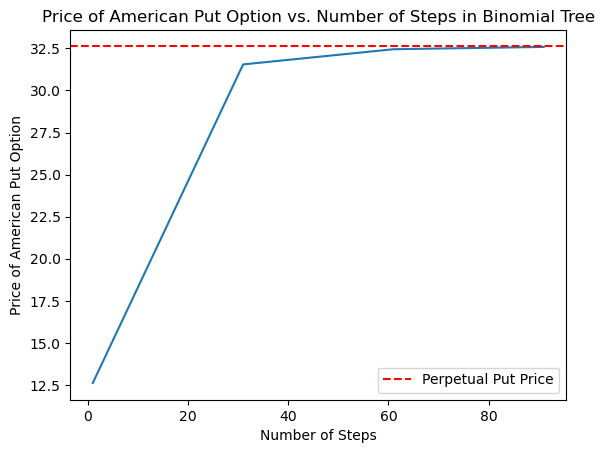

Time taken: 28.57 seconds


In [14]:
#Binomial Tree Convergence to Perpetual Put Price.
t0 = time.time()
#Need to ensure that N is large relative to T so that p is between 0 and 1. Something like N = 5*T.
N = range(1,100,30)
put_prices = []
for n in N:
    #We assume S = 150, K = 150, sigma = 0.25, r = 0.038, and T will increase from 1 to 100.
    put_prices.append(american_put(150,150,0.25,n,0.038,75*n))

plt.plot(N,put_prices)
plt.axhline(y=perpetual_put(150,150,0.25,0.038), color='r', linestyle='--', label='Perpetual Put Price')
plt.xlabel('Number of Steps')
plt.ylabel('Price of American Put Option')
plt.title('Price of American Put Option vs. Number of Steps in Binomial Tree')
plt.legend()

plt.show()

t1 = time.time()
print(f"Time taken: {t1-t0:.2f} seconds")

As we can see, the price of the American-put option does indeed increase with time-to-expiration, but even more than that, we can conclude that the value converges to the value of the perpetual put option. 

Going forward is simply an exercise in computational complexity and accuracy. Doing the same thing with the Longstaff and Schwartz method, we run into similar issues that more simulations and detailed stock paths will be necessary to demenstrate this phenomina. We split the interval $[0,T]$ into $75T$ subintervals as before, and always 20000 simulations in each case. The event of a dip in option value as time increases, or the value going above the perpetual option price typically is a signal that there was not enough simulations at each stage.

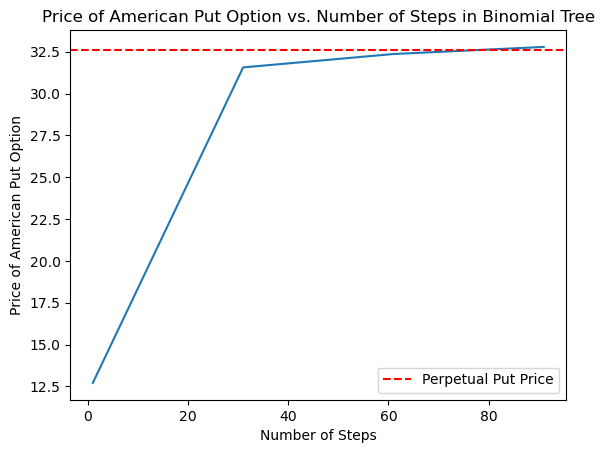

Time taken: 16.54 seconds


In [15]:
#Longstaff-Schwartz Convergence to Perpetual Put Price.
t0 = time.time()
#Need to ensure that N is large relative to T so that p is between 0 and 1. Something like N = 5*T.
N = range(1,100,30)
put_prices = []
for n in N:
    #We assume S = 150, K = 150, sigma = 0.25, r = 0.038, and T will increase from 1 to 100.
    put_prices.append(longstaff_schwartz(150, 150, 0.25, n, 75*n, 20000))

plt.plot(N,put_prices)
plt.axhline(y=perpetual_put(150,150,0.25,0.038), color='r', linestyle='--', label='Perpetual Put Price')
plt.xlabel('Number of Steps')
plt.ylabel('Price of American Put Option')
plt.title('Price of American Put Option vs. Number of Steps in Binomial Tree')
plt.legend()

plt.show()

t1 = time.time()
print(f"Time taken: {t1-t0:.2f} seconds")

Finally, the Bjerksund-Stensland approximation can be expected to compute this task orders of magnitute quicker. This is because there is no need to partition the time interval.

The results of such a test can be found in the code block below.

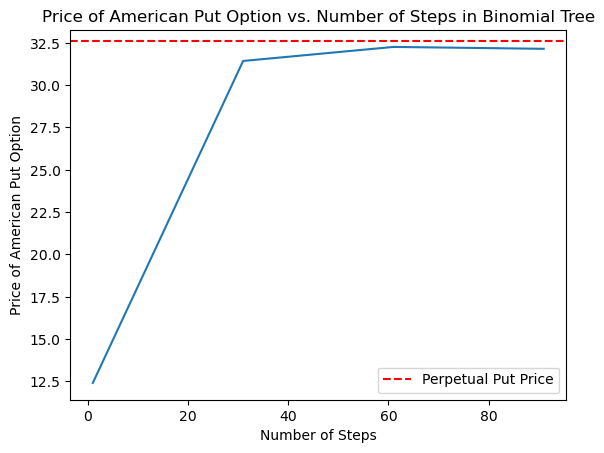

Time taken: 0.07 seconds


In [16]:
#Binomial Tree Convergence to Perpetual Put Price.
t0 = time.time()
#Need to ensure that N is large relative to T so that p is between 0 and 1. Something like N = 5*T.
N = range(1,100,30)
put_prices = []
for n in N:
    #We assume S = 150, K = 150, sigma = 0.25, r = 0.038, and T will increase from 1 to 100.
    put_prices.append(bjerksund_stensland_put(150, 150, n, 0.038, 0.038, 0.25))

plt.plot(N,put_prices)
plt.axhline(y=perpetual_put(150,150,0.25,0.038), color='r', linestyle='--', label='Perpetual Put Price')
plt.xlabel('Number of Steps')
plt.ylabel('Price of American Put Option')
plt.title('Price of American Put Option vs. Number of Steps in Binomial Tree')
plt.legend()

plt.show()

t1 = time.time()
print(f"Time taken: {t1-t0:.2f} seconds")